In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('used_car_listings.csv')[['mileage','price','condition']]

In [5]:
df.head()

,mileage,price,condition
0,46134,19919.0,good
1,16109,19480.0,good
2,173239,4556.0,good
3,36810,11536.0,fair
4,87749,14098.0,good


In [26]:
df.shape

(2068, 3)

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_8420\1007895197.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['mileage'])
C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_8420\1007895197.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


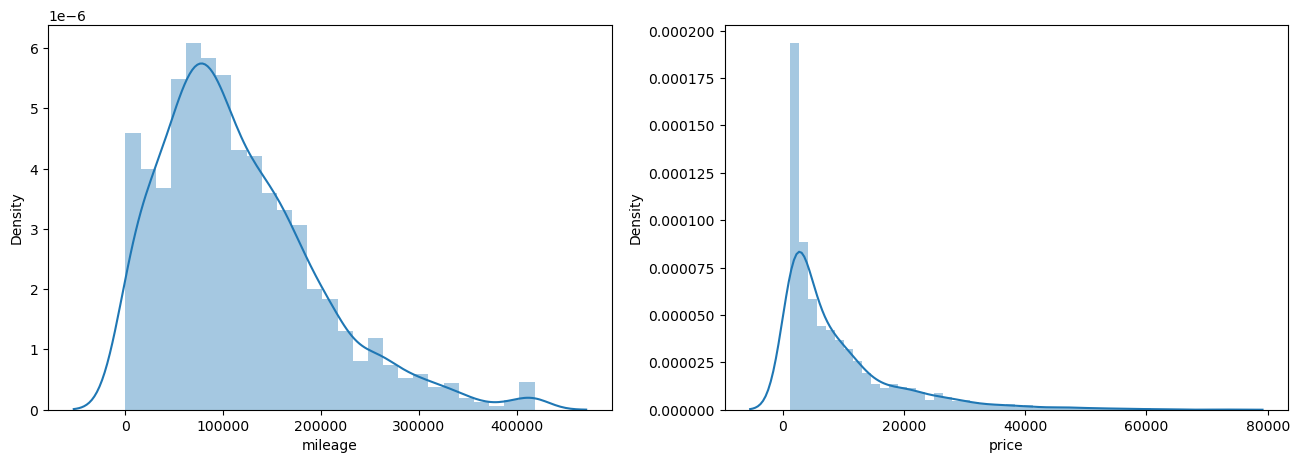

In [6]:
plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
sns.distplot(df['mileage'])

plt.subplot(1,2,2)
sns.distplot(df['price'])

plt.show()

<Axes: xlabel='price'>

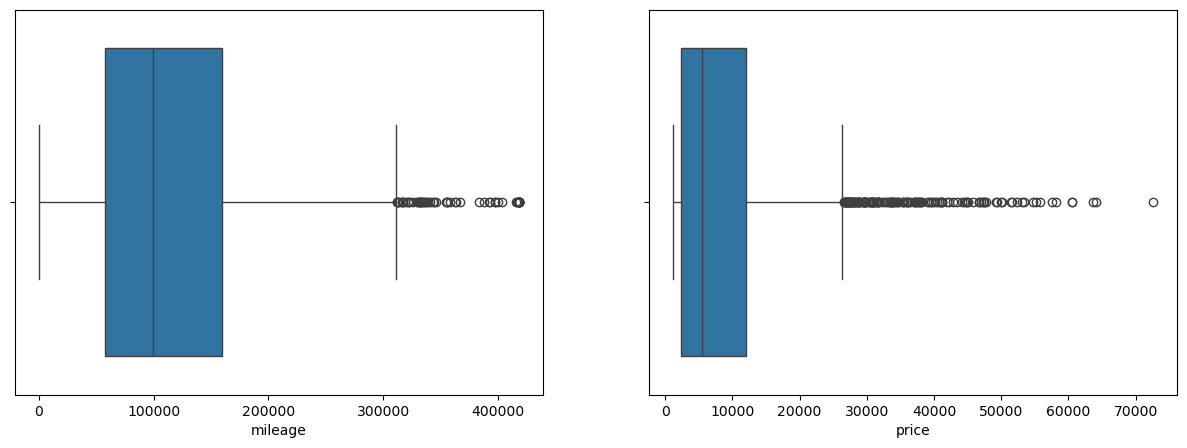

In [9]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['mileage'])
plt.subplot(1,2,2)
sns.boxplot(x=df['price'])

In [10]:
# Finding the IQR
mileage_percentile25 = df['mileage'].quantile(0.25)
mileage_percentile75 = df['mileage'].quantile(0.75)

mileage_IQR = mileage_percentile75 - mileage_percentile25


price_percentile25 = df['price'].quantile(0.25)
price_percentile75 = df['price'].quantile(0.75)

price_IQR = price_percentile75 - price_percentile25

In [11]:
mileage_IQR, price_IQR

(101608.25, 9623.0)

In [55]:
mileage_upperlimit = mileage_percentile75 + 1.5 * mileage_IQR
mileage_lowerlimit = mileage_percentile25 - 1.5 * mileage_IQR

price_upperlimit = price_percentile75 + 1.5 * price_IQR
price_lowerlimit = price_percentile25 - 1.5 * price_IQR

In [56]:
# Trimming

new_df = df[(df['mileage'] > mileage_upperlimit) & (df['price'] > price_upperlimit)] 

In [57]:
new_df.shape

(0, 3)

In [58]:
new_df2 = df.copy()

new_df2['mileage'] = np.where(
    new_df2['mileage'] > mileage_upperlimit,
    mileage_upperlimit,
    np.where(
        new_df2['mileage'] < mileage_lowerlimit,
        mileage_lowerlimit,
        new_df2['mileage']
    )
)


new_df2['price'] = np.where(
    new_df2['price'] > price_upperlimit,
    price_upperlimit,
    np.where(
        new_df2['price'] < price_lowerlimit,
        price_lowerlimit,
        new_df2['price']
    )
)

In [59]:
new_df2.shape

(2068, 3)

<Axes: xlabel='price'>

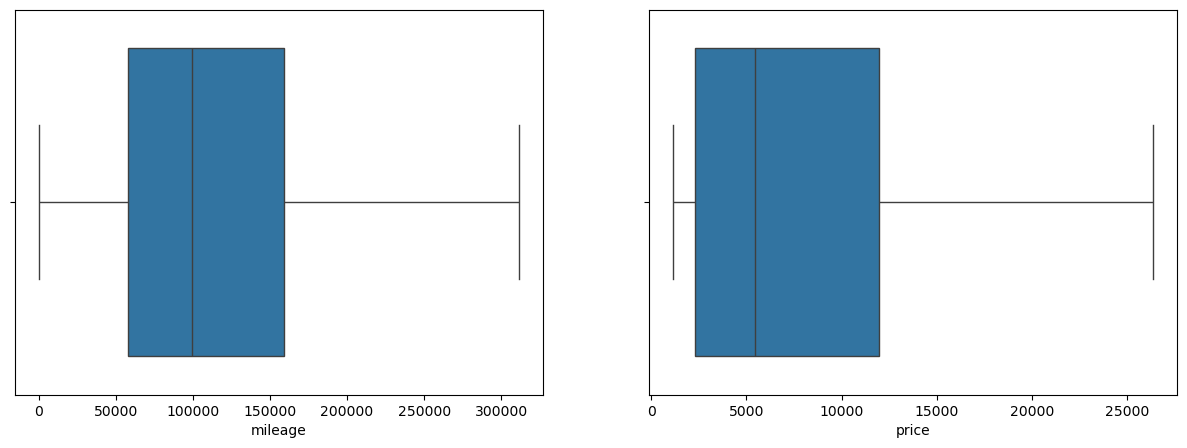

In [60]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(x=new_df2['mileage'])
plt.subplot(1,2,2)
sns.boxplot(x=new_df2['price'])